In [1]:
# !pip install pennylane koreanize_matplotlib scikit-learn -q

In [2]:
import pennylane as qml
from pennylane import numpy as np
import numpy as std_np
import matplotlib.pyplot as plt
import koreanize_matplotlib
from IPython.display import clear_output
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
plt.rcParams['axes.unicode_minus'] = False

In [3]:
# ============================================================
# =====  수정 영역 =====
N_LAYERS  = 2        # Ansatz 레이어 수: 1 / 2 / 3
N_REPEATS = 1        # IQP 반복 횟수: 1 / 2
STEPS     = 80       # 학습 스텝 수: 30 / 50 / 80 / 100
LR        = 0.05     # 학습률: 0.01 / 0.05 / 0.08
PLOT_FEAT = [2, 3]   # 결정경계 시각화에 사용할 2개 feature 인덱스
# ============================================================

In [4]:
N_FEATURES = 4       # Iris feature 4개 전부 사용
N_QUBITS   = 4       # feature 4개 -> 큐빗 4개
N_CLASSES  = 3       # Iris 클래스 3개

print("=" * 60)
print(" Iris 분류  (4 feature → 4 qubit, 3-class 멀티 출력)")
print("=" * 60)
print(f"  N_QUBITS={N_QUBITS}  |  N_LAYERS={N_LAYERS}  |  N_REPEATS={N_REPEATS}")
print(f"  STEPS={STEPS}  |  LR={LR}")

 Iris 분류  (4 feature → 4 qubit, 3-class 멀티 출력)
  N_QUBITS=4  |  N_LAYERS=2  |  N_REPEATS=1
  STEPS=80  |  LR=0.05


In [5]:
# ===========================================================
#  1. 데이터 준비 — 4개 feature 전부 사용
# ===========================================================
iris = load_iris()
X_raw = iris.data            # (150, 4)
y     = iris.target          # (150,)

scaler = MinMaxScaler((0, std_np.pi))
X_scaled = scaler.fit_transform(X_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, stratify=y, random_state=42
)
X_train = np.array(X_train)
X_test  = np.array(X_test)

print(f"\n  feature 이름: {iris.feature_names}")
print(f"  클래스: {list(iris.target_names)}")
print(f"  train: {len(X_train)}개,  test: {len(X_test)}개")
print(f"  입력 형상: {X_train.shape}")


  feature 이름: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
  클래스: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
  train: 105개,  test: 45개
  입력 형상: (105, 4)


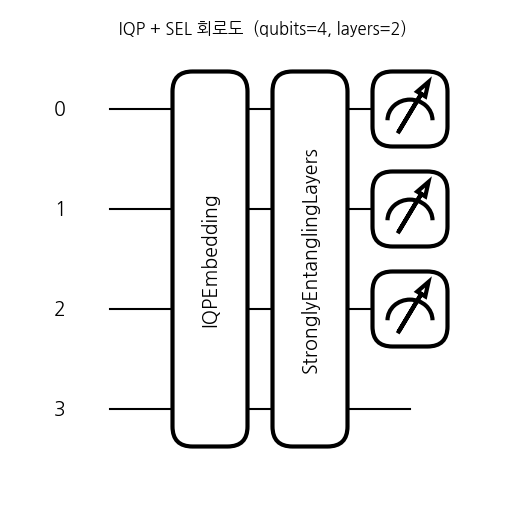

In [6]:
# ===========================================================
#  2. 양자 회로 — 4 qubit, 3 출력 (expval Z0, Z1, Z2)
# ===========================================================
dev = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev)
def circuit(x, w):
    # 데이터 인코딩: IQP Embedding
    qml.IQPEmbedding(x, wires=range(N_QUBITS), n_repeats=N_REPEATS)
    # 파라미터화 Ansatz
    qml.StronglyEntanglingLayers(w, wires=range(N_QUBITS))
    # 3개 큐빗에서 기댓값 측정 → 3-class 출력
    return [qml.expval(qml.PauliZ(i)) for i in range(N_CLASSES)]

# 회로도 시각화
w_shape  = qml.StronglyEntanglingLayers.shape(N_LAYERS, N_QUBITS)
w_sample = np.array(std_np.random.normal(0, 0.1, w_shape))
fig_circ, _ = qml.draw_mpl(circuit, decimals=2)(X_train[0], w_sample)
fig_circ.suptitle(
    f" IQP + SEL 회로도  (qubits={N_QUBITS}, layers={N_LAYERS})",
    fontsize=12
)
fig_circ.savefig("./lab11_a.png", dpi=300, bbox_inches="tight")
plt.show()

In [7]:
# ===========================================================
#  3. 학습 함수 정의
# ===========================================================
def one_hot(y_arr, n_class=N_CLASSES):
    oh = std_np.zeros((len(y_arr), n_class))
    for i, c in enumerate(y_arr):
        oh[i, c] = 1.0
    return oh

def cost(w):
    total = np.array(0.0)
    for x, label in zip(X_train, y_train):
        out    = np.array(circuit(x, w))              # (3,)
        target = np.array(one_hot([label])[0])        # (3,)
        total  = total + np.mean((out - (2 * target - 1)) ** 2)
    return total / len(X_train)

def predict(X, w):
    scores = std_np.array([std_np.array(circuit(x, w)) for x in X])
    return std_np.argmax(scores, axis=1)

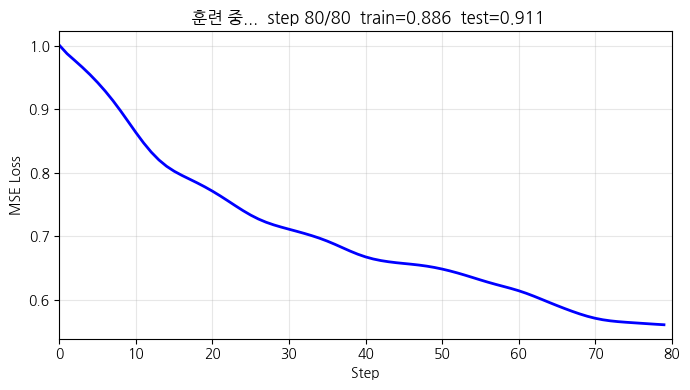

In [8]:
# ===========================================================
#  4. 학습 루프 — 실시간 학습 곡선
# ===========================================================
std_np.random.seed(42)
w = np.array(std_np.random.normal(0, 0.1, w_shape), requires_grad=True)
n_params = int(std_np.prod(w_shape))

print(f"\n  파라미터 형상: {w_shape}  →  총 {n_params}개")
print(f"  출력: expval(Z0), expval(Z1), expval(Z2)  → argmax → 클래스\n")

opt     = qml.AdamOptimizer(LR)
history = []

for step in range(STEPS):
    w, loss = opt.step_and_cost(cost, w)
    history.append(float(loss))

    if step % 10 == 0 or step == STEPS - 1:
        tr_acc = float(std_np.mean(predict(X_train, w) == y_train))
        te_acc = float(std_np.mean(predict(X_test,  w) == y_test))
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(history, 'b-', lw=2)
        ax.set_xlabel("Step")
        ax.set_ylabel("MSE Loss")
        ax.set_title(
            f" 훈련 중...  step {step+1}/{STEPS}  "
            f"train={tr_acc:.3f}  test={te_acc:.3f}"
        )
        ax.set_xlim(0, STEPS)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()


최종 결과
  train Acc: 0.8857
  test  Acc: 0.9111
  파라미터:  24개  (형상: (2, 4, 3))


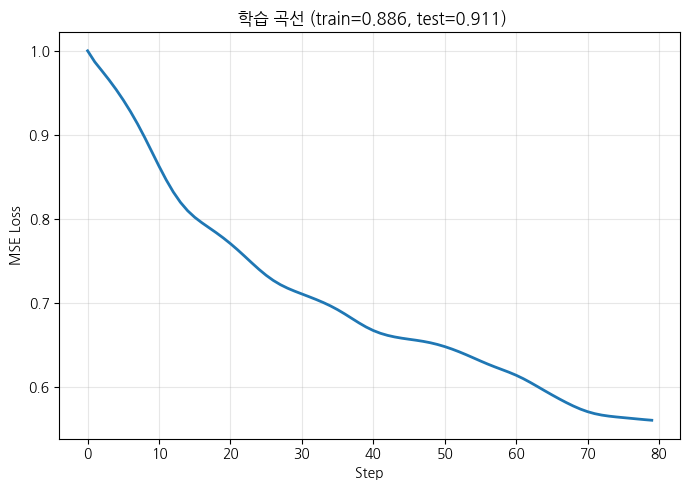

In [9]:
# ===========================================================
#  5. 최종 결과
# ===========================================================
train_acc = float(std_np.mean(predict(X_train, w) == y_train))
test_acc  = float(std_np.mean(predict(X_test,  w) == y_test))

print("\n" + "=" * 60)
print("최종 결과")
print("=" * 60)
print(f"  train Acc: {train_acc:.4f}")
print(f"  test  Acc: {test_acc:.4f}")
print(f"  파라미터:  {n_params}개  (형상: {w_shape})")

# --- 학습 곡선 저장 ---
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(history, lw=2)
ax.set_xlabel("Step")
ax.set_ylabel("MSE Loss")
ax.set_title(f" 학습 곡선 (train={train_acc:.3f}, test={test_acc:.3f})")
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig("./lab11_b.png", dpi=300, bbox_inches="tight")
plt.show()

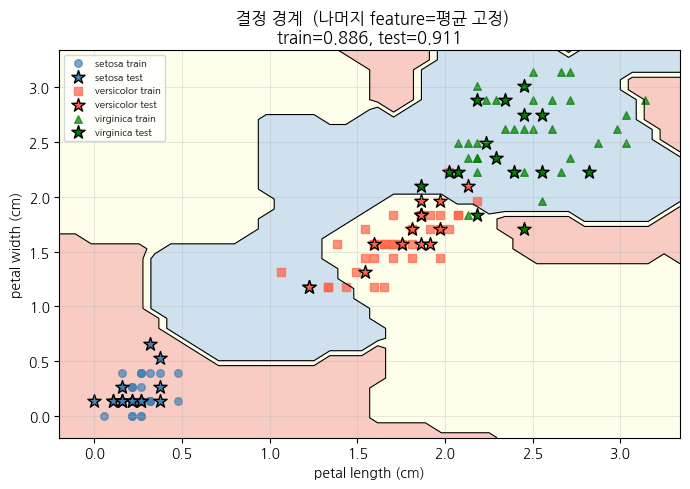

In [10]:
# ===========================================================
#  6. 결정경계 시각화 (PLOT_FEAT 2개 축, 나머지는 평균 고정)
# ===========================================================
f0, f1 = PLOT_FEAT
feat_means = std_np.mean(X_scaled, axis=0)   # 4개 feature의 전체 평균

# 선택한 2개 feature로 mesh grid 생성
margin = 0.2
x_min = X_scaled[:, f0].min() - margin
x_max = X_scaled[:, f0].max() + margin
y_min = X_scaled[:, f1].min() - margin
y_max = X_scaled[:, f1].max() + margin

res = 40  # grid 해상도 (너무 크면 느림)
xx, yy = std_np.meshgrid(
    std_np.linspace(x_min, x_max, res),
    std_np.linspace(y_min, y_max, res)
)

# mesh 위의 각 점에서 나머지 feature는 평균값으로 채움
grid_pts = std_np.tile(feat_means, (xx.ravel().shape[0], 1))  # (res*res, 4)
grid_pts[:, f0] = xx.ravel()
grid_pts[:, f1] = yy.ravel()

Z = predict(np.array(grid_pts), w).reshape(xx.shape)

# --- 결정경계 플롯 ---
fig, ax = plt.subplots(figsize=(7, 5))
ax.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5, 2.5],
            alpha=0.3, cmap='RdYlBu')
ax.contour(xx, yy, Z, levels=[0.5, 1.5], colors='k', linewidths=0.8)

colors  = ['steelblue', 'tomato', 'green']
markers_tr = ['o', 's', '^']

for c, (name, color, mk) in enumerate(
        zip(iris.target_names, colors, markers_tr)):
    mask_tr = y_train == c
    mask_te = y_test  == c
    ax.scatter(X_train[mask_tr, f0], X_train[mask_tr, f1],
               c=color, marker=mk, s=30, alpha=0.7,
               label=f'{name} train')
    ax.scatter(X_test[mask_te, f0], X_test[mask_te, f1],
               c=color, marker='*', s=100, edgecolors='black',
               label=f'{name} test')

ax.set_xlabel(iris.feature_names[f0])
ax.set_ylabel(iris.feature_names[f1])
ax.set_title(
    f" 결정 경계  (나머지 feature=평균 고정)\n"
    f"train={train_acc:.3f}, test={test_acc:.3f}"
)
ax.legend(fontsize=7, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig("./lab11_c.png", dpi=300, bbox_inches="tight")
plt.show()